# import

In [2]:
import strawberryfields as sf
from strawberryfields import ops
from strawberryfields.ops import Sgate, BSgate, MeasureFock
from strawberryfields.tdm import shift_by
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

C:\Users\Sadeq Ismailzadeh\AppData\Roaming\Python\Python311\site-packages\strawberryfields\apps\data\sample.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Theoretical

## Cat state

Final state: <BosonicState: num_modes=2, num_weights=4, pure=None, hbar=2>
[]


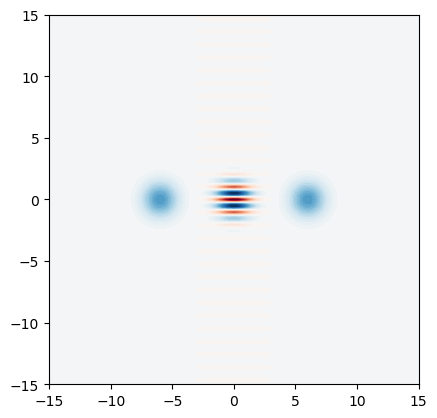

In [4]:
# Simulation and cat state parameters
nmodes = 2
cutoff = 30
q = 4.0
p = 0.0
hbar = 2
# alpha = (q + 1j * p) / np.sqrt(2 * hbar)
alpha = 3 
k = 1

# Squeezing parameter
r = 1.38  # Adjust as needed

prog_cat_bosonic = sf.Program(nmodes)

with prog_cat_bosonic.context as q:
    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[0]


eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
result = eng.run(prog_cat_bosonic)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()  

## squeezed cat state

Final state: <BosonicState: num_modes=2, num_weights=4, pure=None, hbar=2>
[]


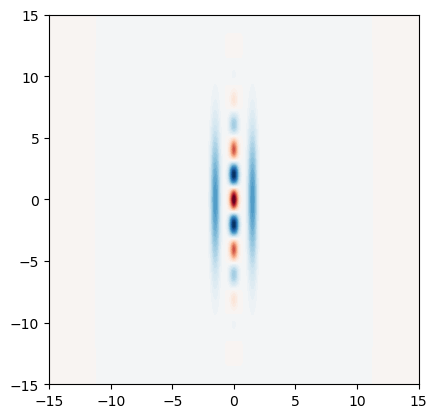

In [14]:
# Simulation and cat state parameters
nmodes = 2
cutoff = 30
q = 4.0
p = 0.0
hbar = 2
# alpha = (q + 1j * p) / np.sqrt(2 * hbar)
alpha = 3 
k = 1

# Squeezing parameter
r = 1.38  # Adjust as needed

prog_cat_bosonic = sf.Program(nmodes)

with prog_cat_bosonic.context as q:
    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[0]
    ops.Sgate(r) | q[0]


eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
result = eng.run(prog_cat_bosonic)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()  

## GKP from squeezed cats

Final state: <BosonicState: num_modes=2, num_weights=16, pure=None, hbar=2>
[[4.38504448]]


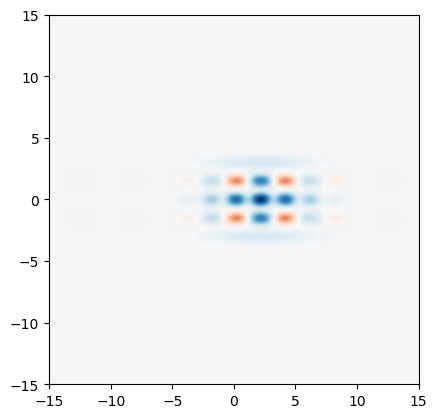

In [11]:
# Simulation and cat state parameters
nmodes = 2
cutoff = 30
q = 4.0
p = 0.0
hbar = 2
# alpha = (q + 1j * p) / np.sqrt(2 * hbar)
alpha = 3 
k = 1

# Squeezing parameter
r = 1.38  # Adjust as needed

prog_cat_bosonic = sf.Program(nmodes)

with prog_cat_bosonic.context as q:
    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[0]
    ops.Rgate(np.pi/2) | q[0]
    ops.Sgate(-r) | q[0]

    ops.Catstate(a=np.absolute(alpha), phi=np.angle(alpha), p=k) | q[1]
    ops.Sgate(r) | q[1]

    ops.CZgate() | (q[0], q[1])
    ops.MeasureHomodyne(phi=np.pi / 2) | q[1]


eng = sf.Engine("bosonic", backend_options={"hbar": hbar})
result = eng.run(prog_cat_bosonic)

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=0, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()  

# Practical

## 1 loop circuit (no agent)

Final state: <FockState: num_modes=3, cutoff=30, pure=True, hbar=2>
[[2. 0.]]


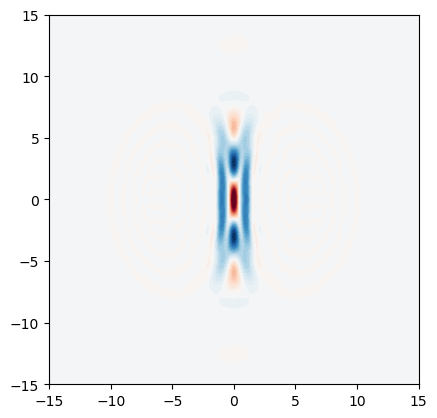

In [7]:
tau =  0.367
theta_bs = np.arccos(tau)
# theta_bs = 1.8
# Squeezing parameter
r = 1.38  # Adjust as needed

# Rotation angle
phi = np.pi/2  # Adjust as needed

# Create a 4-mode quantum program
prog = sf.Program(3)

with prog.context as q:
    # Apply squeezing gates to initialize the states
    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[1]
    ops.BSgate(theta_bs) | (q[0], q[1])
    ops.MeasureFock(select=1) | q[0]

    ops.Sgate(r) | q[0]
    ops.Sgate(-r) | q[2]
    ops.BSgate(theta_bs) | (q[0], q[2])
    ops.MeasureFock(select=2) | q[0]


    ops.Rgate(phi) | q[2]
    ops.CZgate() | (q[2], q[1])
    ops.MeasureHomodyne(phi=np.pi / 2, select=0) | q[2]


# Use the Fock backend (adjust cutoff_dim as needed for convergence)
eng = sf.Engine("fock", backend_options={"cutoff_dim": 30})
# eng = sf.Engine("gaussian")

result = eng.run(prog)

# Output the final state or relevant results
print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()                                              # Display the plot


## main circuit (no agent)

Final state: <FockState: num_modes=2, cutoff=20, pure=True, hbar=2>
[[4]]


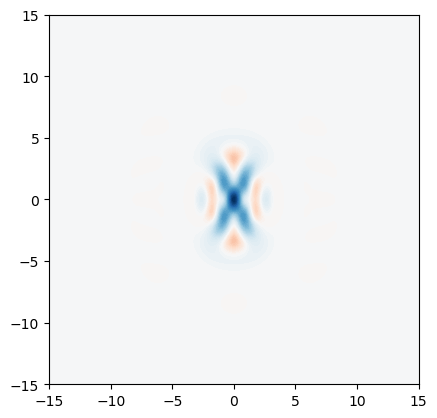

In [ ]:
np.random.seed = 42

# Parameters
m = 3  # Number of steps in the loop
r0 = 1.38  # Squeezing parameter
tau_1 = 0.367
tau_2 = [0] * (m - 1) + [1]  # Switchable mirror for VBS2

# # Convert transmission coefficient to beam splitter angle
# theta_1 = np.arccos(tau_1)
theta_2 = np.arccos(tau_2)

# Create a Strawberry Fields program
eng = sf.Engine("fock", backend_options={"cutoff_dim": 20})
results = []
for j in range(m):
    theta_1 = np.arccos(tau_1)
    r = r0 * (-1) ** j # This will alternate between r0 and -r0 for each iteration

    # Create a new program for each iteration
    prog = sf.Program(2)

    with prog.context as q:
        # Initialize mode 0 with a squeezed vacuum state
        Sgate(r) | q[1]

        # Apply variable beam splitter (VBS1)
        BSgate(theta_1, 0) | (q[0], q[1])

        # Photon-number-resolving measurement (PNR)
        MeasureFock(select=4) | q[0]

        BSgate(theta_2[j], 0) | (q[0], q[1])  # Fully reflective mirror

        # if tau_2[j] == 0:
        #     q = shift_by(q, 1)


    # Run the simulation and store result
    result = eng.run(prog)
    results.append(result)

# Use the last result for plotting
result = results[-1]

print("Final state:", result.state)
print(result.samples)

xvec = np.linspace(-15, 15, 401)                        # Create vector of 401 points from -15 to 15 for phase-space coordinates
W = result.state.wigner(mode=1, xvec=xvec, pvec=xvec)   # Calculate Wigner function for quantum state (mode 1)
scale = np.max(W.real)                                  # Get max value for symmetric color scaling
nrm = mpl.colors.Normalize(-scale, scale)               # Create symmetric color normalization
plt.axes().set_aspect("equal")                          # Set square aspect ratio for phase-space plot
plt.contourf(xvec, xvec, W, 60, cmap=cm.RdBu, norm=nrm) # Plot Wigner function using filled contours (red: positive, blue: negative)
plt.show()

